动态规划算法要求马尔可夫决策过程时已知的，但大多数情况下，数据的分布情况时未知的，只能通过和环境的交互，通过采样得到数据进学习 

**时序差分算法**

核心：用当前获得的奖励加上下一个状态的价值估计作为当前状态获得的回报
$$
V(s_t) \leftarrow V(s_t) + \alpha\big[r_t + \gamma V(s_{t+1}) - V(s_t)\big]
$$
$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\big[r_t + \gamma Q(s_{t+1},a_{t+1}) - Q(s_t,a_t)\big]
$$
可以证明，经过多次迭代后，$V(s),Q(s,a)$ 会收敛到策略 $\pi$ 的价值函数和状态动作价值函数

**Sarsa 算法**

根据动作价值选取当前状态下的最优动作，和环境进行交互，再根据得到的数据更新动作价值估计

**核心：策略提升可以在策略评估未完成的情况下进行**

为了防止有些状态动作对 $(s,a)$ 没有被选中，可以使用 $\epsilon - \text{Greedy}$ 算法\
*注：$(s,a)$、$(s',a')$ 的选取都使用 $\epsilon - \text{Greedy}$*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class CliffWalkingEnv:
    def __init__(self, ncol, nrow):
        self.nrow = nrow
        self.ncol = ncol
        self.x = 0
        self.y = self.nrow - 1

    def step(self, action):
        change = [[0, -1], [0, 1], [-1, 0], [1, 0]]
        # 边界钳位，不能走出网格
        self.x = min(self.ncol - 1, max(0, self.x + change[action][0]))
        self.y = min(self.nrow - 1, max(0, self.y + change[action][1]))
        next_state = self.y * self.ncol + self.x
        reward = -1
        done = False
        # 判断是否踏入悬崖/终点
        if self.y == self.nrow - 1 and self.x > 0:
            done = True
            if self.x != self.ncol - 1:
                reward = -100
        return next_state, reward, done

    def reset(self):
        self.x = 0
        self.y = self.nrow - 1
        return self.y * self.ncol + self.x

In [2]:
class Sarsa:
    """ Sarsa 算法"""

    def __init__(self, ncol, nrow, epsilon, alpha, gamma, n_action=4):
        # Q表 Q[state][action]
        self.Q_table = np.zeros([nrow * ncol, n_action])
        self.n_action = n_action
        self.alpha = alpha      # 学习率
        self.gamma = gamma      # 折扣因子
        self.epsilon = epsilon  # ε-贪婪

    def take_action(self, state):
        """ ε-贪婪选取动作 """

        if np.random.random() < self.epsilon:
            # 探索：随机动作
            action = np.random.randint(self.n_action)
        else:
            # 利用：贪心选最大Q
            action = np.argmax(self.Q_table[state])
        return action

    def best_action(self, state):
        """ 获取最优动作掩码"""

        q_max = np.max(self.Q_table[state])
        a = [0 for _ in range(self.n_action)]
        for i in range(self.n_action):
            if self.Q_table[state, i] == q_max:
                a[i] = 1
        return a

    def update(self, s0, a0, r, s1, a1):
        """ Sarsa 更新公式 """
        
        td_error = r + self.gamma * self.Q_table[s1, a1] - self.Q_table[s0, a0]
        self.Q_table[s0, a0] += self.alpha * td_error


Iteration 49: 100%|██████████| 20/20 [00:00<00:00, 6658.68it/s, episode=4920, return=-19.200]


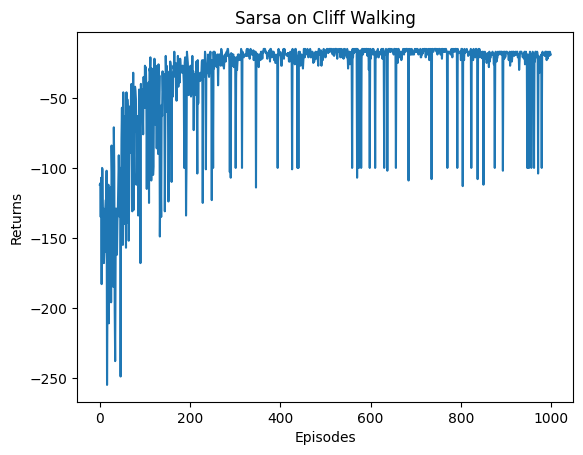

In [3]:
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
np.random.seed(0)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = Sarsa(ncol, nrow, epsilon, alpha, gamma)
num_episodes = 1000

return_list = []
num_iteration = 50
for _ in range(num_iteration):
    with tqdm(total=int(num_episodes/num_iteration), desc='Iteration %d' % _) as pbar:
        for i_episode in range(int(num_episodes/num_iteration)):
            episode_return = 0
            state = env.reset()
            action = agent.take_action(state)
            done = False
            while not done:
                next_state, reward, done = env.step(action)
                next_action = agent.take_action(next_state)
                episode_return += reward
                agent.update(state, action, reward, next_state, next_action)
                state = next_state
                action = next_action
            return_list.append(episode_return)
            if (i_episode+1) % 10 == 0:
                pbar.set_postfix({'episode': '%d' % (num_episodes/10 * _ + i_episode+1),
                                  'return': '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Sarsa on Cliff Walking')
plt.show()

In [4]:
def print_agent(agent, env, action_meaning, disaster=[], end=[]):

    for i in range(env.nrow):
        for j in range(env.ncol):
            s = i * env.ncol + j

            if s in disaster:
                print('****', end=' ')
            elif s in end:
                print('EEEE', end=' ')
            else:
                # 获取当前状态下所有最优动作掩码 [0,1,0,1]
                a = agent.best_action(s)
                pi_str = ''
                for k in range(len(action_meaning)):
                    # 如果a[k]>0 → 该动作是最优动作，打印方向符号，否则打印'o'占位
                    pi_str += action_meaning[k] if a[k] > 0 else 'o'
                print(pi_str, end=' ')
        print()

In [5]:
action_meaning = ['^', 'v', '<', '>']
print('Sarsa算法最终收敛得到的策略：')
print_agent(agent, env, action_meaning, disaster=list(range(37,47)), end=[47])

Sarsa算法最终收敛得到的策略：
ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo 
ooo> ooo> ^ooo ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo 
^ooo ^ooo ^ooo ^ooo ^ooo ^ooo ooo> ^ooo ^ooo ^ooo ooo> ovoo 
^ooo **** **** **** **** **** **** **** **** **** **** EEEE 


**多步 Sarsa 算法**

- 蒙特卡洛方法：无偏（采样每一步的奖励，不使用价值估计），但方差较大（状态转移具有不确定性）
- Sarsa 算法：有偏，但方差较小

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha\big[r_t + \gamma r_{t+1} + \cdots + \gamma^n Q(s_{t+n},a_{t+n}) - Q(s_t,a_t)\big]
$$

In [6]:
class nstep_Sarsa:
    """n步Sarsa算法"""

    def __init__(self, n, ncol, nrow, epsilon, alpha, gamma, n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])
        self.n_action = n_action
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n = n  # n步参数
        # 轨迹缓存列表，保存历史 s,a,r
        self.state_list = []
        self.action_list = []
        self.reward_list = []

    def take_action(self, state):
        """ε-贪婪选取动作"""

        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action

    def best_action(self, state):
        """获取最优动作掩码"""

        q_max = np.max(self.Q_table[state])
        a = [0 for _ in range(self.n_action)]
        for i in range(self.n_action):
            if self.Q_table[state, i] == q_max:
                a[i] = 1
        return a

    def update(self, s0, a0, r, s1, a1, done):
        """n步回报计算 + Q表更新"""

        # 缓存当前转移片段
        self.state_list.append(s0)
        self.action_list.append(a0)
        self.reward_list.append(r)

        # 条件1：缓存长度 >= n，可以执行一次n步更新
        if len(self.state_list) == self.n:
            # n步目标：G = r_t + γ r_{t+1}+...+γ^{n-1}r_{t+n-1} + γ^n Q(s_{t+n},a_{t+n})
            G = self.Q_table[s1, a1]
            # 反向递推计算折扣回报
            for i in reversed(range(self.n)):
                G = self.reward_list[i] + self.gamma * G
            # 取出最早需要更新的 (s,a)
            s = self.state_list.pop(0)
            a = self.action_list.pop(0)
            self.reward_list.pop(0)
            # 增量更新
            self.Q_table[s, a] += self.alpha * (G - self.Q_table[s, a])

        # 条件2：回合终止done=True，清空缓存，依次更新剩下不足n步的片段
        if done:
            while len(self.state_list) > 0:
                G = 0
                for i in reversed(range(len(self.state_list))):
                    G = self.reward_list[i] + self.gamma * G
                s = self.state_list.pop(0)
                a = self.action_list.pop(0)
                self.reward_list.pop(0)
                self.Q_table[s, a] += self.alpha * (G - self.Q_table[s, a])


Iteration 49: 100%|██████████| 20/20 [00:00<00:00, 5231.76it/s, episode=4920.0, return=-20.1]


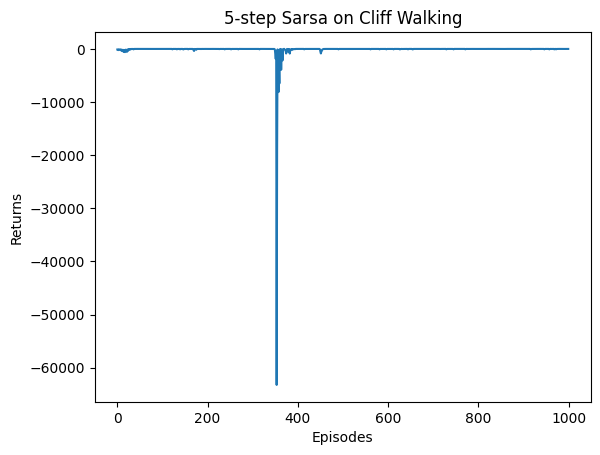

In [7]:
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
np.random.seed(0)
n_step = 5
alpha = 0.1
epsilon = 0.1
gamma = 0.9
agent = nstep_Sarsa(n_step, ncol, nrow, epsilon, alpha, gamma)
num_episodes = 1000

return_list = []
num_iteration = 50
for _ in range(num_iteration):
    with tqdm(total=int(num_episodes/num_iteration), desc=f'Iteration {_}') as pbar:
        for i_episode in range(int(num_episodes/num_iteration)):
            episode_return = 0
            state = env.reset()
            action = agent.take_action(state)
            done = False
            while not done:
                next_state, reward, done = env.step(action)
                next_action = agent.take_action(next_state)
                episode_return += reward
                agent.update(state, action, reward, next_state, next_action, done)
                state = next_state
                action = next_action
            return_list.append(episode_return)
            if (i_episode+1) % 10 == 0:
                pbar.set_postfix({'episode': num_episodes/10*_+i_episode+1,
                                  'return': np.mean(return_list[-10:])})
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title(f'{n_step}-step Sarsa on Cliff Walking')
plt.show()

In [ ]:
print('5步Sarsa算法最终收敛得到的策略：')
print_agent(agent, env, action_meaning, disaster=list(range(37,47)), end=[47])

5步Sarsa算法最终收敛得到的策略：
ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo 
^ooo ^ooo ooo> ^ooo oo<o ^ooo ^ooo ^ooo ooo> ^ooo ^ooo ovoo 
^ooo oo<o ^ooo ooo> ^ooo ^ooo oo<o ooo> ^ooo ^ooo ooo> ovoo 
^ooo **** **** **** **** **** **** **** **** **** **** EEEE 


**Q-learning 算法**

本质：异策略的 Sarsa 算法

- $(s,a)$：通过 $\epsilon - \text{Greedy}$ 算法进行采样
- $(s',a')$：直接取 $a' = \argmax_{a} Q(s',a)$

In [9]:
class QLearning:
    """Q-learning 算法：Off-Policy 离轨策略时序差分控制"""

    def __init__(self, ncol, nrow, epsilon, alpha, gamma, n_action=4):
        self.Q_table = np.zeros([nrow * ncol, n_action])  # Q(s,a)表格
        self.n_action = n_action
        self.alpha = alpha        # 学习率
        self.gamma = gamma        # 折扣因子
        self.epsilon = epsilon    # ε-贪婪参数

    def take_action(self, state):
        """ε-贪婪策略，用于轨迹采样（行为策略）"""

        if np.random.random() < self.epsilon:
            action = np.random.randint(self.n_action)
        else:
            action = np.argmax(self.Q_table[state])
        return action

    def best_action(self, state):
        """获取贪心最优动作掩码"""

        Q_max = np.max(self.Q_table[state])
        a = [0 for _ in range(self.n_action)]
        for i in range(self.n_action):
            if self.Q_table[state, i] == Q_max:
                a[i] = 1
        return a

    def update(self, s0, a0, r, s1):
        """Q-learning 更新公式"""

        td_error = r + self.gamma * self.Q_table[s1].max() - self.Q_table[s0, a0]
        self.Q_table[s0, a0] += self.alpha * td_error


Iteration 9: 100%|██████████| 50/50 [00:00<00:00, 9400.05it/s, episode=500, return=-61.7] 


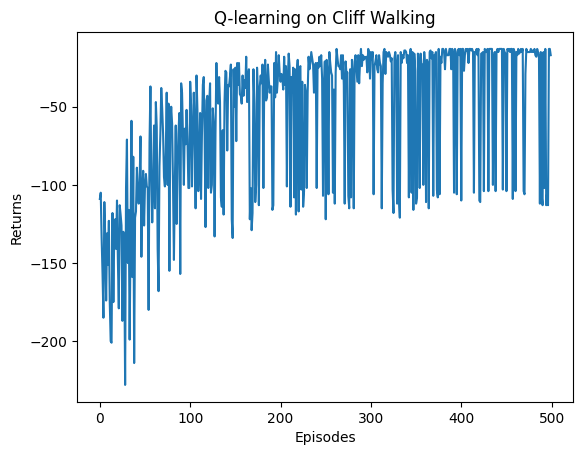

In [10]:
ncol = 12
nrow = 4
env = CliffWalkingEnv(ncol, nrow)
np.random.seed(0)
epsilon = 0.1
alpha = 0.1
gamma = 0.9
agent = QLearning(ncol, nrow, epsilon, alpha, gamma)
num_episodes = 500

return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes/10), desc=f"Iteration {i}") as pbar:
        for i_episode in range(int(num_episodes/10)):
            episode_return = 0
            state = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, done = env.step(action)
                episode_return += reward
                # 对比Sarsa：不需要提前采样next_action
                agent.update(state, action, reward, next_state)
                state = next_state
            return_list.append(episode_return)
            if (i_episode+1) % 10 == 0:
                pbar.set_postfix({'episode': num_episodes/10*i + i_episode+1,
                                  'return': np.mean(return_list[-10:])})
            pbar.update(1)

episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Q-learning on Cliff Walking')
plt.show()

In [11]:
print('Q-learning算法最终收敛得到的策略：')
print_agent(agent, env, action_meaning, disaster=list(range(37,47)), end=[47])

Q-learning算法最终收敛得到的策略：
^ooo ovoo ovoo ^ooo ^ooo ovoo ooo> ^ooo ^ooo ooo> ooo> ovoo 
ooo> ooo> ooo> ooo> ooo> ooo> ^ooo ooo> ooo> ooo> ooo> ovoo 
ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ooo> ovoo 
^ooo **** **** **** **** **** **** **** **** **** **** EEEE 
